In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

os.chdir(r'D:\Programs\bluestock_mf_capstone')
conn = sqlite3.connect(r'data\db\bluestock_mf.db')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

print("Connected to DB! Current Directory:", os.getcwd())

Connected to DB! Current Directory: D:\Programs\bluestock_mf_capstone


In [2]:
# Daily and Annualised Returns

# 1. Loading NAV data perfectly sorted by fund and date using "date as nav_date"
query_nav = """
    SELECT amfi_code, date as nav_date, nav 
    FROM fact_nav 
    ORDER BY amfi_code, date
"""
df_nav = pd.read_sql(query_nav, conn, parse_dates=['nav_date'])

# 2. Computing Daily Returns
df_nav['daily_return'] = df_nav.groupby('amfi_code')['nav'].pct_change()

# 3. Computing Annualised Return
def calc_annualised_return(group):
    returns = group['daily_return'].dropna()
    n_days = len(returns)
    if n_days == 0:
        return np.nan
    # Formula: (1 + daily_return).prod()^(252/n) - 1
    compounded = (1 + returns).prod()
    return (compounded ** (252 / n_days)) - 1

df_ann_return = df_nav.groupby('amfi_code').apply(calc_annualised_return).reset_index()
df_ann_return.columns = ['amfi_code', 'annualised_return']

df_nav.to_csv(r'data\processed\returns_computed.csv', index=False)
print("Task 1 Complete: returns_computed.csv saved.")
df_ann_return.head()

Task 1 Complete: returns_computed.csv saved.


,amfi_code,annualised_return
0,100016,0.018121
1,100025,0.030550
2,100033,0.199217
3,101206,0.157011
4,101207,0.054121


In [3]:
# Compound Annual Growth Rate (CAGR)
def compute_cagr(group, periods):
    if len(group) < periods:
        return np.nan # Not enough history
    
    nav_end = group['nav'].iloc[-1]
    nav_start = group['nav'].iloc[-periods]
    n_years = periods / 252
    
    return ((nav_end / nav_start) ** (1 / n_years)) - 1

cagr_data = []
for amfi_code, group in df_nav.groupby('amfi_code'):
    cagr_data.append({
        'amfi_code': amfi_code,
        'cagr_1yr': compute_cagr(group, 252),
        'cagr_3yr': compute_cagr(group, 756),
        'cagr_5yr': compute_cagr(group, 1260) 
    })

df_cagr = pd.DataFrame(cagr_data)
df_cagr.to_csv(r'data\processed\cagr_report.csv', index=False)
print("Task 2 Complete: cagr_report.csv saved.")

Task 2 Complete: cagr_report.csv saved.


In [4]:
# Risk Metrics (Sharpe & Sortino)
daily_rf = 0.065 / 252

def compute_risk_metrics(group):
    returns = group['daily_return'].dropna()
    if len(returns) == 0:
        return pd.Series({'sharpe_ratio': np.nan, 'sortino_ratio': np.nan})
    
    excess_returns = returns - daily_rf
    
    # Sharpe Ratio
    sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)
    
    # Sortino Ratio (Downside deviation only)
    downside_returns = excess_returns[excess_returns < 0]
    downside_std = downside_returns.std()
    sortino = (excess_returns.mean() / downside_std) * np.sqrt(252) if downside_std != 0 else np.nan
    
    return pd.Series({'sharpe_ratio': sharpe, 'sortino_ratio': sortino})

df_risk = df_nav.groupby('amfi_code').apply(compute_risk_metrics).reset_index()

df_risk[['amfi_code', 'sharpe_ratio']].to_csv(r'data\processed\sharpe_values.csv', index=False)
df_risk[['amfi_code', 'sortino_ratio']].to_csv(r'data\processed\sortino_values.csv', index=False)
print("Task 3 & 4 Complete: Risk CSVs saved.")

Task 3 & 4 Complete: Risk CSVs saved.


In [5]:
# Alpha and Beta vs NIFTY100 (Fixed Spacing)
import pandas as pd
from scipy import stats

# 1. Preparing the Benchmark Data
df_bench = pd.read_csv(r'data\raw\10_benchmark_indices.csv', parse_dates=['date'])

# THE FIX: Use exactly 'NIFTY100' (no space)
df_nifty100 = df_bench[df_bench['index_name'] == 'NIFTY100'].sort_values('date')
df_nifty100['bench_return'] = df_nifty100['close_value'].pct_change()
df_nifty100 = df_nifty100.rename(columns={'date': 'nav_date'})[['nav_date', 'bench_return']].dropna()

# 2. Preparing the Fund Data and Merge
df_returns_clean = df_nav[['amfi_code', 'nav_date', 'daily_return']].dropna()
df_merged = pd.merge(df_returns_clean, df_nifty100, on='nav_date', how='inner')

# 3. Calculating Alpha and Beta
alpha_beta_data = []
for amfi_code, group in df_merged.groupby('amfi_code'):
    slope, intercept, r_value, p_value, std_err = stats.linregress(group['bench_return'], group['daily_return'])
    
    alpha_beta_data.append({
        'amfi_code': amfi_code,
        'alpha': intercept * 252, # Annualised Alpha
        'beta': slope
    })

df_alpha_beta = pd.DataFrame(alpha_beta_data)
df_alpha_beta.to_csv(r'data\processed\alpha_beta.csv', index=False)
print("Task 5 Complete: alpha_beta.csv saved. Shape:", df_alpha_beta.shape)

Task 5 Complete: alpha_beta.csv saved. Shape: (40, 3)


In [6]:
# Maximum Drawdown
def compute_max_drawdown(group):
    # running_max tracks the highest NAV seen up to the current date
    running_max = group['nav'].cummax()
    drawdown = (group['nav'] / running_max) - 1
    
    # max_dd is the lowest negative value
    max_dd = drawdown.min()
    return max_dd

df_drawdown = df_nav.groupby('amfi_code').apply(compute_max_drawdown).reset_index()
df_drawdown.columns = ['amfi_code', 'max_drawdown']

df_drawdown.to_csv(r'data\processed\max_drawdown.csv', index=False)
print("Task 6 Complete: max_drawdown.csv saved.")

Task 6 Complete: max_drawdown.csv saved.


In [7]:
# Build Fund Scorecard (The Ironclad Data Type Fix)
import pandas as pd

# 1. Fetching Expense Ratio from dim_fund
df_expense = pd.read_sql("SELECT amfi_code, scheme_name, expense_ratio_pct FROM dim_fund", conn)

# 2. Forcing 'amfi_code' to be a string across all dataframes before merging
df_cagr['amfi_code'] = df_cagr['amfi_code'].astype(str)
df_risk['amfi_code'] = df_risk['amfi_code'].astype(str)
df_alpha_beta['amfi_code'] = df_alpha_beta['amfi_code'].astype(str)
df_drawdown['amfi_code'] = df_drawdown['amfi_code'].astype(str)
df_expense['amfi_code'] = df_expense['amfi_code'].astype(str)

# 3. Merging all metrics into one master DataFrame
df_scorecard = df_cagr[['amfi_code', 'cagr_3yr']].merge(df_risk, on='amfi_code')
df_scorecard = df_scorecard.merge(df_alpha_beta, on='amfi_code')
df_scorecard = df_scorecard.merge(df_drawdown, on='amfi_code')
df_scorecard = df_scorecard.merge(df_expense, on='amfi_code')

# Droping NaNs (funds without a 3-year history won't get a composite score)
df_scorecard = df_scorecard.dropna(subset=['cagr_3yr'])

# 4. Calculating Percentile Ranks (0 to 100)
# Standard rank: higher metric = higher score
rank_3yr = df_scorecard['cagr_3yr'].rank(pct=True) * 100
rank_sharpe = df_scorecard['sharpe_ratio'].rank(pct=True) * 100
rank_alpha = df_scorecard['alpha'].rank(pct=True) * 100

# Inverse rank: Lower expense is better, so ascending=False
rank_expense = df_scorecard['expense_ratio_pct'].rank(pct=True, ascending=False) * 100

# Max DD is negative, so ascending=True properly rewards the higher (-0.10 is better than -0.50)
rank_dd = df_scorecard['max_drawdown'].rank(pct=True, ascending=True) * 100

# 5. Applying Weights
df_scorecard['composite_score'] = (
    (0.30 * rank_3yr) + 
    (0.25 * rank_sharpe) + 
    (0.20 * rank_alpha) + 
    (0.15 * rank_expense) + 
    (0.10 * rank_dd)
).round(2)

# Sorting from best to worst
df_scorecard = df_scorecard.sort_values('composite_score', ascending=False)
df_scorecard.to_csv(r'data\processed\fund_scorecard.csv', index=False)
print("Task 7 Complete: fund_scorecard.csv saved.")
df_scorecard[['scheme_name', 'composite_score', 'sharpe_ratio', 'alpha']].head()

Task 7 Complete: fund_scorecard.csv saved.


,scheme_name,composite_score,sharpe_ratio,alpha
34,Mirae Asset Large Cap Fund - Regular - Growth,86.25,1.068224,0.269838
30,Kotak Flexicap Fund - Regular - Growth,82.75,0.965561,0.273305
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,80.75,0.808268,0.271954
19,SBI Bluechip Fund - Regular Plan - Growth,77.94,0.860977,0.232010
25,ICICI Pru Midcap Fund - Regular - Growth,76.88,0.883256,0.292636


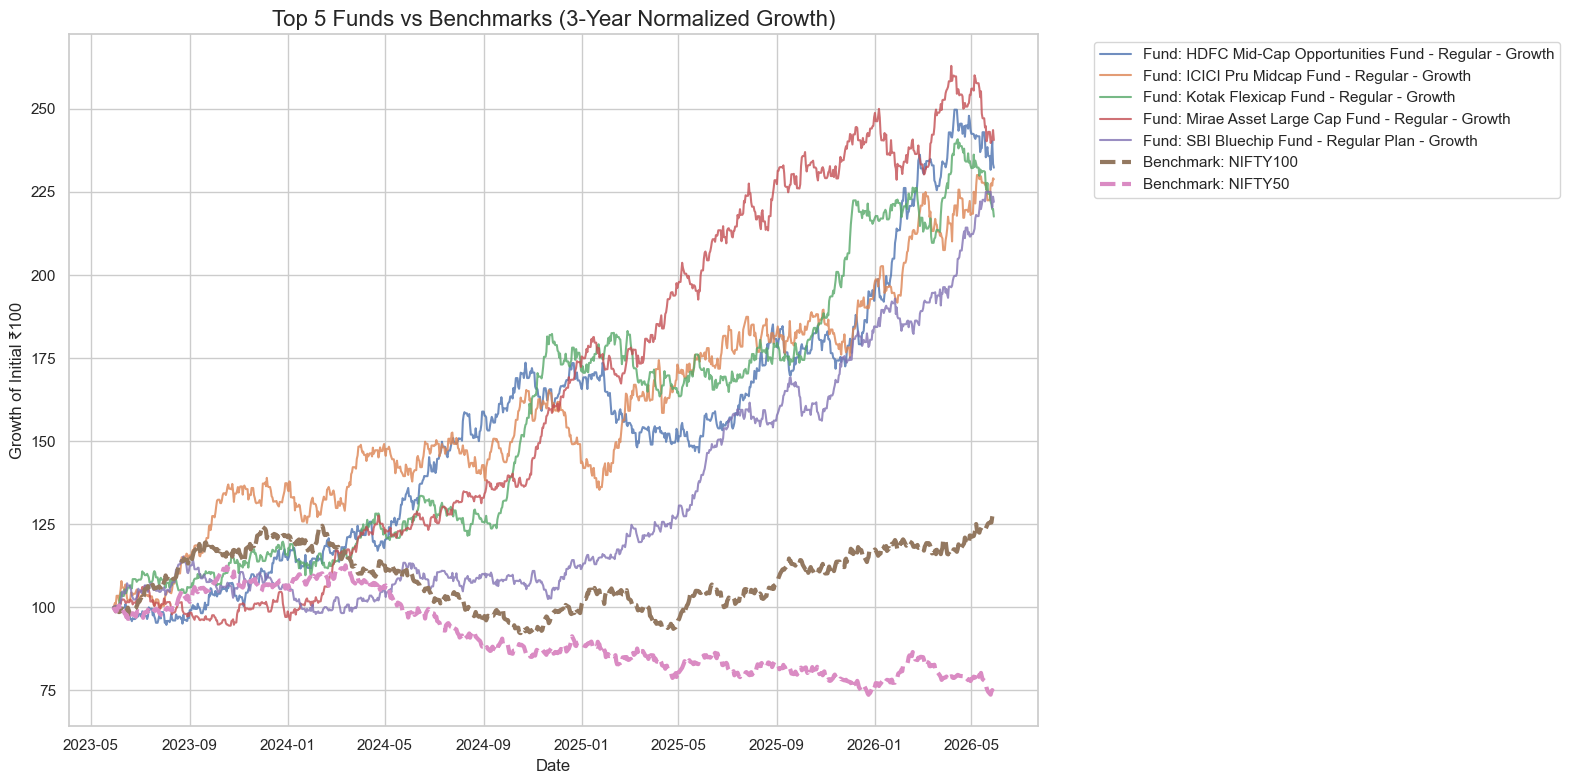


--- Tracking Error (vs NIFTY100) ---
Mirae Asset Large Cap Fund - Regular - Growth: 0.1897
Kotak Flexicap Fund - Regular - Growth: 0.2064
HDFC Mid-Cap Opportunities Fund - Regular - Growth: 0.2287
SBI Bluechip Fund - Regular Plan - Growth: 0.1912
ICICI Pru Midcap Fund - Regular - Growth: 0.2320


In [8]:
# Benchmark Comparison Chart
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Top 5 AMFI Codes
top_5_codes = df_scorecard.head(5)['amfi_code'].tolist()

# Ensuring df_nav amfi_code is string for filtering the chart data
df_nav['amfi_code'] = df_nav['amfi_code'].astype(str)
df_top5 = df_nav[df_nav['amfi_code'].isin(top_5_codes)].merge(df_expense, on='amfi_code')

# 2. NIFTY50 and NIFTY100 data
df_benchmarks = df_bench[df_bench['index_name'].isin(['NIFTY50', 'NIFTY100'])].rename(columns={'date': 'nav_date'})

# Filtering for the last 3 years
max_date = df_top5['nav_date'].max()
start_date = max_date - pd.DateOffset(years=3)

df_top5_3yr = df_top5[df_top5['nav_date'] >= start_date]
df_bench_3yr = df_benchmarks[df_benchmarks['nav_date'] >= start_date]

# 3. Normalizing values to 100 at the start date for fair comparison
plt.figure(figsize=(16, 8))

for name, group in df_top5_3yr.groupby('scheme_name'):
    normalized = (group['nav'] / group['nav'].iloc[0]) * 100
    plt.plot(group['nav_date'], normalized, label=f"Fund: {name}", alpha=0.8)

for name, group in df_bench_3yr.groupby('index_name'):
    normalized = (group['close_value'] / group['close_value'].iloc[0]) * 100
    plt.plot(group['nav_date'], normalized, label=f"Benchmark: {name}", linewidth=3, linestyle='--')

plt.title('Top 5 Funds vs Benchmarks (3-Year Normalized Growth)', fontsize=16)
plt.ylabel('Growth of Initial ₹100')
plt.xlabel('Date')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig(r'reports\benchmark_chart.png')
plt.show()

# 4. Computing Tracking Error for Top 5
print("\n--- Tracking Error (vs NIFTY100) ---")

df_merged['amfi_code'] = df_merged['amfi_code'].astype(str)

for code in top_5_codes:
    fund_data = df_merged[df_merged['amfi_code'] == code]
    fund_returns = fund_data['daily_return']
    bench_returns = fund_data['bench_return']
    tracking_error = (fund_returns - bench_returns).std() * np.sqrt(252)
    name = df_expense[df_expense['amfi_code'] == code]['scheme_name'].iloc[0]
    print(f"{name}: {tracking_error:.4f}")